# Experiment 7: Surprise + Moving Obstacle Avoidance

Experiment 6 assumed all obstacle trajectories were known from the start. This experiment handles surprise obstacles that spawn at arbitrary points during the rollout.


## Spatial Coupling Function

Same as Experiment 6 with one addition: if any component of an obstacle position is NaN (has'nt spawned yet), that obstacle is skipped entirely for that timestep.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Performance_measuring import test_dmp_performance

def spatial_coupling_OA(
        y, 
        ydot,
        obstacles, 
        gamma=1000.0, 
        beta=6.0, 
        eps=1e-9
        ):

    y    = np.asarray(y).reshape(-1,)
    ydot = np.asarray(ydot).reshape(-1,)

    d_dim    = y.shape[0]
    Ct_total = np.zeros(d_dim)

    vnorm = np.linalg.norm(ydot)
    if vnorm < eps:
        return Ct_total

    for o in obstacles:
        o = np.asarray(o).reshape(-1,)

        if not np.all(np.isfinite(o)): # if any obstacle position is not finite, skip it    
            continue

        dvec  = o - y
        dnorm = np.linalg.norm(dvec)
        if dnorm < eps:
            continue

        cosang = np.dot(dvec, ydot) / (dnorm * vnorm + eps)
        cosang = np.clip(cosang, -1.0, 1.0)
        psi    = np.arccos(cosang)

        if d_dim == 2:
            cross_z = dvec[0]*ydot[1] - dvec[1]*ydot[0]
            sign    = 1.0 if cross_z >= 0 else -1.0
            Rydot   = sign * np.array([-ydot[1], ydot[0]])

        elif d_dim == 3:
            r     = np.cross(dvec, ydot)
            rnorm = np.linalg.norm(r)

            if rnorm < eps:
                a = np.array([1.0, 0.0, 0.0])
                if abs(np.dot(a, ydot) / (np.linalg.norm(a) * vnorm + eps)) > 0.9:
                    a = np.array([0.0, 1.0, 0.0])
                r     = np.cross(a, ydot)
                rnorm = np.linalg.norm(r)
                if rnorm < eps:
                    continue

            rhat  = r / (rnorm + eps)
            Rydot = np.cross(rhat, ydot) + rhat * np.dot(rhat, ydot)

        else:
            raise ValueError("Only 2D or 3D supported.")

        Ct_total += gamma * Rydot * psi * np.exp(-beta * psi)

    return Ct_total


ModuleNotFoundError: No module named 'Performance_measuring'

## DMP with Moving Obstacle Avoidance

Identical to Experiment 6. The NaN handling is inside spatial_coupling_OA, so this function doesn't need to change.

In [ ]:
def dmp_discrete_3d_moving_OA(
    pos, 
    dt, 
    obs_paths,
    kp=150.0, 
    kv=25.0, 
    alpha=5.0, 
    basis_num=40,
    speed=1.0,
    start_shift=None,
    goal_shift=None,
    spatial_scale=None,
    init_vel_scale=1.0,
    init_vel_offset=None,
    oa_gamma=1000.0,
    oa_beta=6.0
):   
    pos = np.asarray(pos) #
    assert pos.ndim == 2 and pos.shape[0] == 3, "pos must be shape (3, T)"
    assert speed > 0, "speed must be > 0"

    T = pos.shape[1] 

    tau_demo = dt * T
    tau_new  = tau_demo / speed 
    T_new = int(np.round(tau_new / dt))
    T_new = max(T_new, 2)

    if obs_paths is None:
        obs_paths = []
    elif isinstance(obs_paths, np.ndarray):
        obs_paths = [obs_paths]

    for k in range(len(obs_paths)):
        obs_paths[k] = np.asarray(obs_paths[k]).reshape(3, T_new)
        assert obs_paths[k].shape == (3, T_new), "obstacle path must be shape (3, T_new)"

    vel = np.gradient(pos, axis=-1) / dt 
    acc = np.gradient(vel, axis=-1) / dt 

    goal = pos[:, -1]
    demo_start = pos[:, 0]
    demo_goal  = pos[:, -1]

    if start_shift is None:
        start_shift = np.zeros(3)
    if goal_shift is None:
        goal_shift = np.zeros(3)

    start_shift = np.asarray(start_shift).reshape(3,)
    goal_shift  = np.asarray(goal_shift).reshape(3,)

    newStart = demo_start + start_shift
    newGoal  = demo_goal  + goal_shift

    if init_vel_offset is None:
        init_vel_offset = np.zeros(3)
    init_vel_offset = np.asarray(init_vel_offset).reshape(3,)


    demo_displacement = demo_goal - demo_start
    new_displacement  = newGoal - newStart

    if spatial_scale is None:
        spatial_scale = np.ones(3)
        for d in range(3):
            if abs(demo_displacement[d]) > 1e-8:
                spatial_scale[d] = new_displacement[d] / demo_displacement[d]
    else:
        spatial_scale = np.asarray(spatial_scale).reshape(3,)

    u = np.zeros(basis_num)
    c = np.zeros(basis_num)
    h = np.zeros(basis_num)

    for i in range(basis_num):
        u[i] = (1.0 / basis_num) * i
        c[i] = np.exp(-alpha * u[i])

    for i in range(basis_num - 1):
        h[i] = 0.5 / ((0.65 * (c[i+1] - c[i]))**2) 
    h[basis_num - 1] = h[basis_num - 2]

    Phi = np.zeros(basis_num)
    Phi_total = np.zeros((T, basis_num))
    force = np.zeros((T, 3))

    s = 1.0
    for i in range(T):
        s = -alpha * s * dt / tau_demo  + s

        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum += Phi[b]
        Phi = Phi / addsum * s
        Phi_total[i, :] = Phi

        force[i, :] = (tau_demo*tau_demo)*acc[:, i] - kp*(goal - pos[:, i]) + tau_demo*kv*vel[:, i]

    trainPattern = np.matmul(np.linalg.pinv(Phi_total), force)  # (basis_num, 3)

    DMP_pos = np.zeros((3, T_new))
    DMP_vel = np.zeros((3, T_new))
    DMP_acc = np.zeros((3, T_new))

    DMP_pos[:, 0] = newStart 
    DMP_vel[:, 0] = init_vel_scale * vel[:, 0] + init_vel_offset

    s = 1.0
    for i in range(T_new - 1):
        s = -alpha * s * dt / tau_new + s
        addsum = 0.0
        
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum = addsum + Phi[b]

        newForce = np.matmul(Phi / addsum, trainPattern) * s * spatial_scale

        obstacles_i = [p[:, i] for p in obs_paths]

        if len(obstacles_i) == 0:
            Ct = 0.0
        else:
            # obstacle avoidance coupling term
            Ct = spatial_coupling_OA(
                DMP_pos[:, i],
                DMP_vel[:, i],
                obstacles_i,
                gamma=oa_gamma,
                beta=oa_beta
            )

        # transformation system
        DMP_acc[:, i] = (kp*(newGoal - DMP_pos[:, i]) - tau_new*kv*DMP_vel[:, i] + newForce + Ct) / (tau_new**2)
        DMP_pos[:, i+1] = DMP_pos[:, i] + DMP_vel[:, i] * dt
        DMP_vel[:, i+1] = DMP_vel[:, i] + DMP_acc[:, i] * dt

    return DMP_pos, DMP_vel, DMP_acc, trainPattern, tau_new, newStart, newGoal

## Obstacle Path Builder

make_object_path creates a (3, T_new) obstacle trajectory using: an anchor point on the reference path, an optional offset, a motion function that returns a time-varying delta, and a spawn index indicating when the obstacle should spawn

In [ ]:
def make_object_path(
    ref_path,
    t,
    anchor_idx,
    offset=(0.0, 0.0, 0.0),
    motion_fn=None, # allow for differnt motions to be created using the same function
    spawn_idx=0,
):
    ref_path = np.asarray(ref_path, dtype=float)
    assert ref_path.ndim == 2 and ref_path.shape[0] == 3

    t = np.asarray(t, dtype=float).reshape(-1,) # obstacle path time steps
    T_new = ref_path.shape[1]

    offset = np.asarray(offset, dtype=float).reshape(3,)
    anchor_point = ref_path[:, anchor_idx].copy()

    # Create with NaN (obstacle doesn't exist before spawn)
    obj = np.full((3, T_new), np.nan, dtype=float)

    if motion_fn is None:
        # Static obstacle
        obj[:, spawn_idx:] = (anchor_point + offset).reshape(3, 1)
        return obj

    t0 = t[spawn_idx] # time when the obstacle spawns
    for i in range(spawn_idx, T_new):
        t_local = t[i] - t0
        i_local = i - spawn_idx
        delta   = np.asarray(motion_fn(t_local, i_local, anchor_point, offset), dtype=float).reshape(3,)
        obj[:, i] = anchor_point + offset + delta

    return obj

## Plotting Helper (NaN-Aware)

Same 4-frame layout as Experiment 6, but NaN positions are filtered out when computing axis limits and when drawing obstacle trails. If an obstacle hasn't spawned by a given frame, it simply doesn't appear.

In [ ]:
def plot_dmp_4frames_moving(pos, DMP_pos, obj_paths=None, newGoal=None):
    if obj_paths is None:
        obj_list = []
    elif isinstance(obj_paths, np.ndarray):# if a single array is given, convert to list of one array
        obj_list = [obj_paths]
    else:
        obj_list = list(obj_paths)

    dem_len = DMP_pos.shape[1]

    for k in range(len(obj_list)): # convert to numpy and check shape
        obj_list[k] = np.asarray(obj_list[k], dtype=float)
        assert obj_list[k].shape == (3, dem_len), f"Object {k} must be shape (3, {dem_len})"

    # combine all points to compute a shared axis range
    P = np.column_stack([pos[0], pos[1], pos[2]])
    Q = np.column_stack([DMP_pos[0], DMP_pos[1], DMP_pos[2]])
    pts = [P, Q]

    for p in obj_list:
        obj_pts = np.column_stack([p[0], p[1], p[2]])
        obj_pts = obj_pts[np.all(np.isfinite(obj_pts), axis=1)] # if any points are NaN or inf, remove them for plotting
        if len(obj_pts) > 0:
            pts.append(obj_pts)

    if newGoal is not None:
        pts.append(np.asarray(newGoal, dtype=float).reshape(1, 3))

    pts_all = np.vstack(pts)
    
    # compute axis limits
    mins = pts_all.min(axis=0)
    maxs = pts_all.max(axis=0)
    buffer = float(np.max(maxs - mins)) / 8.0
    min_val = float(np.min(mins)) - buffer
    max_val = float(np.max(maxs)) + buffer

    # pick 4 frame indices across the rollout
    frame_idx = np.linspace(0, dem_len - 1, 4).astype(int)

    fig = plt.figure(figsize=(10, 10))
    for j, idx in enumerate(frame_idx, start=1):
        ax = fig.add_subplot(2, 2, j, projection="3d")

        ax.plot(pos[0], pos[1], pos[2], label="demo")
        ax.plot(DMP_pos[0], DMP_pos[1], DMP_pos[2], label="DMP")

        ee = DMP_pos[:, idx]
        ax.scatter(ee[0], ee[1], ee[2], marker='*', s=120, label="DMP now")

        for k, p in enumerate(obj_list):
            obj_so_far = p[:, :idx+1]
            mask = np.all(np.isfinite(obj_so_far), axis=0) # mask to filter out any points that are NaN 

            if np.any(mask):
                ax.plot(obj_so_far[0, mask], obj_so_far[1, mask], obj_so_far[2, mask], label=f"obj{k+1} path") # plot path so far (only valid points)

            obj_now = p[:, idx]
            if np.all(np.isfinite(obj_now)):
                ax.scatter(obj_now[0], obj_now[1], obj_now[2], marker='o', s=80, label=f"obj{k+1}")

        if newGoal is not None:
            g = np.asarray(newGoal, dtype=float).reshape(3,)
            ax.scatter(g[0], g[1], g[2], marker='x', s=70, label="goal")
        else:
            ax.scatter(pos[0, -1], pos[1, -1], pos[2, -1], marker='x', s=70, label="goal")

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.set_zlim(min_val, max_val)

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")

        ax.set_title(f"Frame {j}")
        ax.legend()

    plt.tight_layout()
    plt.show()

## Motion Functions

Small library of obstacle motion behaviours. 

In [ ]:
# motion functions
# They receive the time since spawn (t_local) which can be used with V to get the distance moved since spawn. 
# when repeated this creates the entire path post-spawn.

def motion_cross_x(t_local, i_local, anchor, offset, v=0.6):
    # moves along +x after spawn
    return np.array([v * t_local, 0.0, 0.0])

def motion_cross_y(t_local, i_local, anchor, offset, v=0.6):
    # moves along +y after spawn
    return np.array([0.0, v * t_local, 0.0])

def motion_drift_diag(t_local, i_local, anchor, offset, v=(0.0, 0.5, -0.1)):
    # simple diagonal drift with velocity v
    v = np.asarray(v, float)
    return v * t_local

def motion_circle_xy(t_local, i_local, anchor, offset, R=0.22, w=2*np.pi*0.9):
    # circle in XY plane
    return np.array([R*np.cos(w*t_local) - R, R*np.sin(w*t_local), 0.0])

## Example 1 — S-Curve Trajectory with One Moving Obstacle and One Surprise Obstacle

=== Performance Metrics ===
final_goal_error: 0.01993162457964314
RMS_tracking_error: 0.05146836622454222
min_distance_each_obstacle: [0.14369439286484523, 0.04307324657580318]
min_distance_overall: 0.04307324657580318
original_path_length: 2.3134719003509945
DMP_path_length: 2.4120437759286597


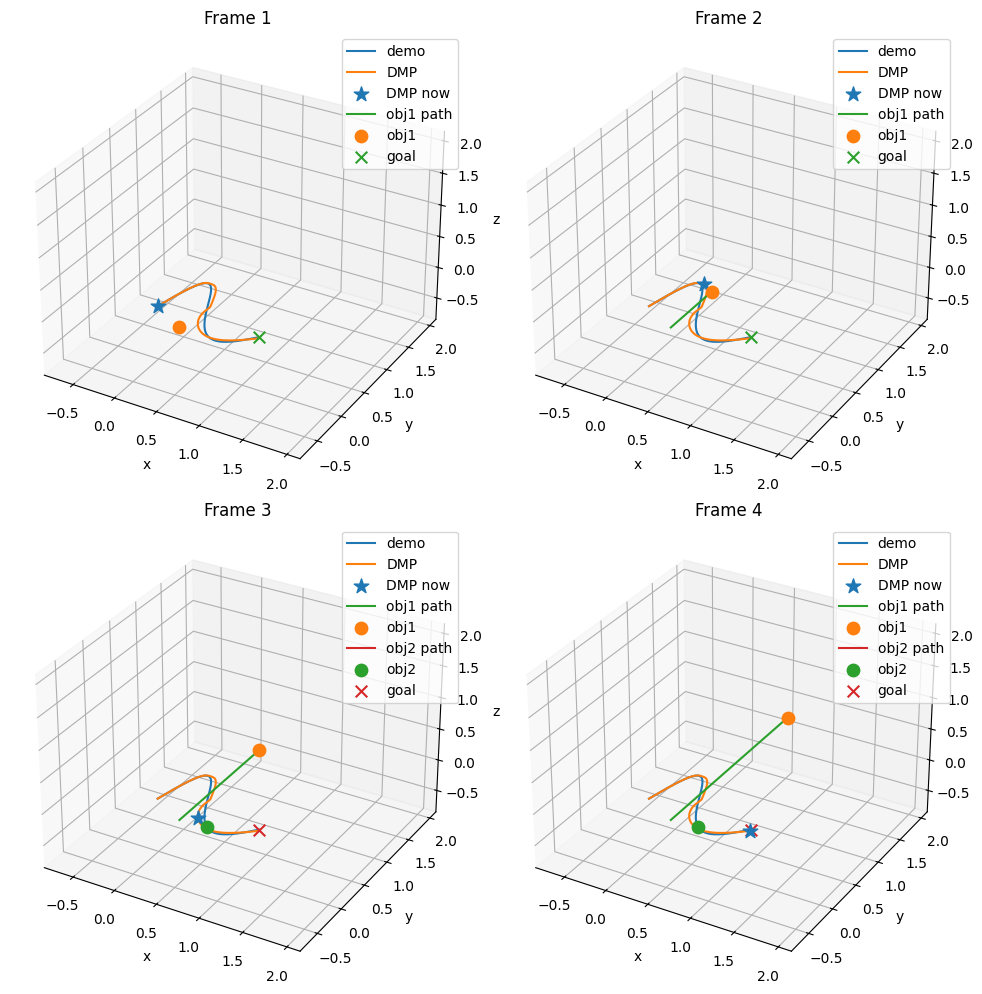

In [ ]:

def gen_3d_demo_s_curve(dt=0.005, tau=2.0, x_len=1.2, y_amp=0.45, z_amp=0.25):
    T = int(np.round(tau / dt))
    t = np.linspace(0, tau, T)
    u = t / tau

    x = x_len * u
    y = y_amp * np.sin(2 * np.pi * u)
    z = z_amp * np.sin(np.pi * u)

    return np.vstack([x, y, z]), t


dt = 0.005
pos, t_demo = gen_3d_demo_s_curve(dt=dt, tau=2.0, x_len=1.2, y_amp=0.45, z_amp=0.25)

speed = 1.0
T_new = max(int(np.round(pos.shape[1] / speed)), 2)
tau_demo = dt * pos.shape[1]
tau_new = tau_demo / speed
t_new = np.linspace(0.0, tau_new, T_new)
ref_path = pos[:, :T_new]

mid = T_new // 2

obs1 = make_object_path(
    ref_path=ref_path,
    t=t_new,
    anchor_idx=mid,
    offset=(0.0, -0.55, 0.05),
    motion_fn=lambda tl, il, a, off: motion_cross_y(tl, il, a, off, v=1.2), #need use of lambda to pass velocity parameter to motion function
    spawn_idx=0
)

spawn2 = int(0.50 * T_new)
anchor2 = int(0.70 * T_new)
obs2 = make_object_path(
    ref_path=ref_path,
    t=t_new,
    anchor_idx=anchor2,
    offset=(0, 0, 0),
    spawn_idx=spawn2
)

obs_paths = [obs1, obs2]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_moving_OA(pos, dt, obs_paths, speed=speed, oa_gamma=1000.0, oa_beta=6.0
)

from Performance_measuring import test_dmp_performance

point_error, metrics = test_dmp_performance( pos, DMP_pos, obstacle_paths=obs_paths
)

print("=== Performance Metrics ===")
for k, v in metrics.items():
    print(f"{k}: {v}")

plot_dmp_4frames_moving(pos, DMP_pos, obj_paths=obs_paths, newGoal=newGoal)


## Example 2 — Helix Trajectory with Two Surprise Moving Obstacles

=== Performance Metrics ===
final_goal_error: 0.09509496020229079
RMS_tracking_error: 0.07864909275124674
min_distance_each_obstacle: [0.145735171693988, 0.29616981801960757]
min_distance_overall: 0.145735171693988
original_path_length: 4.612483353862877
DMP_path_length: 4.730968291294643


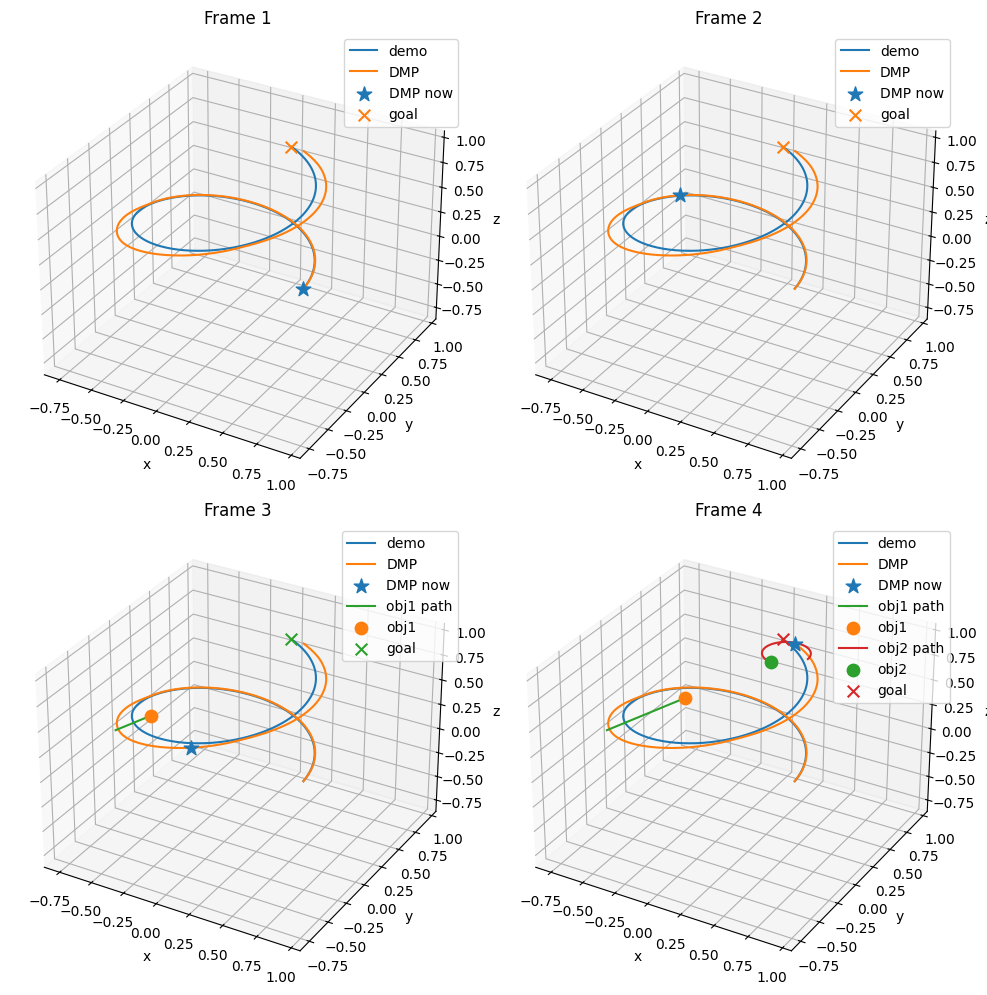

In [ ]:

def gen_3d_demo_helix_segment(dt=0.005, tau=2.0, R=0.6, turns=1.2, z_len=0.9):
    T = int(np.round(tau / dt))
    t = np.linspace(0, tau, T)
    u = t / tau

    theta = 2 * np.pi * turns * u
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    z = z_len * u

    return np.vstack([x, y, z]), t


dt = 0.005
pos, t_demo = gen_3d_demo_helix_segment(dt=dt, tau=2.0, R=0.6, turns=1.2, z_len=0.9)

speed = 1.0
T_new = max(int(np.round(pos.shape[1] /speed)), 2)
tau_demo = dt * pos.shape[1]
tau_new = tau_demo / speed
t_new = np.linspace(0.0, tau_new, T_new)
ref_path = pos[:, :T_new]

spawnA = int(0.40 * T_new)
anchorA = int(0.50 * T_new)
obsA = make_object_path(
    ref_path=ref_path,
    t=t_new,
    anchor_idx=anchorA,
    offset=(0.10, -0.35, 0.15),
    motion_fn=lambda tl, il, a, off: motion_drift_diag(tl, il, a, off, v=(0.0, 0.8, -0.25)),
    spawn_idx=spawnA
)

spawnB = int(0.72 * T_new)
anchorB = int(0.88 * T_new)
obsB = make_object_path(
    ref_path=ref_path,
    t=t_new,
    anchor_idx=anchorB,
    offset=(-0.10, 0.20, 0.10),
    motion_fn=lambda tl, il, a, off: motion_circle_xy(tl, il, a, off, R=0.16, w=2 * np.pi * 1.3),
    spawn_idx=spawnB
)

obs_paths = [obsA, obsB]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_moving_OA(pos, dt, obs_paths, speed=speed, oa_gamma=1200.0, oa_beta=6.0
)

point_error, metrics = test_dmp_performance(pos, DMP_pos, obstacle_paths=obs_paths
)

print("=== Performance Metrics ===")
for k, v in metrics.items():
    print(f"{k}: {v}")
    
plot_dmp_4frames_moving(pos, DMP_pos, obj_paths=obs_paths, newGoal=newGoal)
